In [280]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score 
from sklearn.preprocessing import MinMaxScaler 
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt 
import seaborn as sns 
from keras.layers import Input, Dense 
from keras.models import Model, Sequential 
from keras import regularizers 
from sklearn.preprocessing import LabelEncoder

# Extração de Texto
from nltk.corpus import stopwords
import nltk
import warnings

# Suprimir todos os warnings
warnings.filterwarnings("ignore")



In [281]:
# Loading the dataset 
df = pd.read_csv('./cor_da_justica.csv')   

In [282]:
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementaDetalhada"] if x["ementaDetalhada"] == str(x["ementaDetalhada"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementa_principal"] if x["ementa_principal"] != str("vazio") else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords"] if x["keywords"] == str(x["keywords"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords_principal"] if x["keywords_principal"] == str(x["keywords_principal"]) else x["ementa"] , axis=1)

In [283]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#") | (df["cor"] == "NÃO DIVULGÁVEL")].index).reset_index(drop=True)

# df["cor"].loc[(df["cor"] == "AMARELA") | (df["cor"] == "INDÍGENA") | (df["cor"] == "PARDA") | (df["cor"] == "PRETA")] = "OUTROS"

In [284]:
df = df.drop(columns=['Unnamed: 0'])
df = df.drop_duplicates()
df = df.dropna(subset=["ementa"])

In [285]:
df['cor'].value_counts()

cor
BRANCA      3711
PARDA       1025
PRETA        224
INDÍGENA     180
AMARELA      103
Name: count, dtype: int64

In [286]:
# nltk.download('stopwords')

In [287]:
df['sigla_partido'].value_counts()

sigla_partido
PL               1163
UNIÃO             726
PT                457
REPUBLICANOS      396
PP                386
PSOL              316
NOVO              309
PSD               266
MDB               253
PDT               183
PSB               135
CIDADANIA         119
PODE              118
PROS               90
PRD                68
AVANTE             48
PCdoB              40
SOLIDARIEDADE      40
PSDB               31
PTB                27
PSC                16
PV                 15
PR                 12
PPS                 5
DEM                 5
PSL                 4
PMDB                4
PHS                 3
REDE                3
S.PART.             2
PRP                 1
PMN                 1
PRB                 1
Name: count, dtype: int64

In [288]:
df_branco = df[df['cor'] == 'BRANCA']
df_pardos = df[df['cor'] == 'PARDA']
df_negros = df[df['cor'] == 'PRETA']
contagem = df_branco.groupby('sigla_partido').size()
contagem_pardos = df_pardos.groupby('sigla_partido').size()
contagem_negras = df_negros.groupby('sigla_partido').size()

In [289]:
partidos = df.loc[(df['sigla_partido'].isin(['PL', 'UNIÃO', 'PT', 'PP', 'REPUBLICANOS']))].reset_index(drop=True)

In [290]:
sigla = partidos.groupby('sigla_partido')

In [291]:
PL = sigla.get_group('PL').reset_index()
PT = sigla.get_group('PT').reset_index()
PP = sigla.get_group('PP').reset_index()
REPUBLICANOS = sigla.get_group('REPUBLICANOS').reset_index()
UNIÃO = sigla.get_group('UNIÃO').reset_index()


In [292]:
partidos_teste = [PL, UNIÃO, PT, PP, REPUBLICANOS,]
count = []
porcentagem_total = []
partido_teste = ["PL", 'UNIÃO', "PT", "PP", 'REPUBLICANOS']
    

for pos, part in enumerate(partidos_teste):
    count.append(part.value_counts(subset=['cor']))
    porcentagem = []

    for i in range(len(count[pos])):
        porcentagem.append((count[pos][i]/count[pos].sum())*100)

    count[pos] = pd.DataFrame(count[pos])
    count[pos]['porcentagem'] = porcentagem
    count[pos] = count[pos].style.set_caption(caption=partido_teste[pos])
    



In [293]:
# PL
count[0]

,count,porcentagem
cor,,
BRANCA,719,61.822872
PARDA,392,33.705933
PRETA,29,2.493551
INDÍGENA,20,1.719690
AMARELA,3,0.257954


In [294]:
#UNIÂO 
count[1]

,count,porcentagem
cor,,
BRANCA,531,73.140496
PARDA,108,14.876033
AMARELA,55,7.575758
PRETA,31,4.269972
INDÍGENA,1,0.137741


In [295]:
# PT
count[2]

,count,porcentagem
cor,,
BRANCA,351,76.805252
PRETA,53,11.597374
PARDA,50,10.940919
AMARELA,3,0.656455


In [296]:
# PP
count[3]

,count,porcentagem
cor,,
BRANCA,325,84.196891
PARDA,56,14.507772
PRETA,3,0.777202
AMARELA,2,0.518135


In [297]:
# REPUBLICANOS
count[4]

,count,porcentagem
cor,,
BRANCA,297,75.000000
PARDA,93,23.484848
PRETA,4,1.010101
AMARELA,1,0.252525
INDÍGENA,1,0.252525


In [298]:
tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(partidos["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab = ' '.join(vocab)


In [299]:
X = X.toarray()

In [300]:
lab = LabelEncoder()
y = lab.fit_transform(partidos['sigla_partido'])

In [301]:
partidos["sigla_partido"].value_counts()

sigla_partido
PL              1163
UNIÃO            726
PT               457
REPUBLICANOS     396
PP               386
Name: count, dtype: int64

In [302]:
teste = pd.DataFrame(y)
teste.value_counts()

0
0    1163
4     726
2     457
3     396
1     386
Name: count, dtype: int64

In [303]:
y

array([2, 2, 2, ..., 4, 0, 3])

In [304]:

def tsne_plot(x, y): 
      
    # Setting the plotting background 
    sns.set_theme(style ="whitegrid") 
      
    tsne = TSNE(n_components = 2, random_state = 42) 
      
    # Reducing the dimensionality of the data 
    X_transformed = tsne.fit_transform(x) 

    plt.figure(figsize =(12, 8)) 
      
    # Building the scatter plot 
    plt.scatter(X_transformed[np.where(y == 0), 0],  
                X_transformed[np.where(y == 0), 1], 
                marker ='o', color ='y', linewidth =1, 
                alpha = 0.8, label ='PL') 
    plt.scatter(X_transformed[np.where(y == 1), 0], 
                X_transformed[np.where(y == 1), 1], 
                marker ='o', color ='k', linewidth =1, 
                alpha = 0.8, label ='PP') 
    plt.scatter(X_transformed[np.where(y == 2), 0], 
                X_transformed[np.where(y == 2), 1], 
                marker ='o', color ='r', linewidth =1, 
                alpha = 0.8, label ='PT') 
    plt.scatter(X_transformed[np.where(y == 3), 0], 
                X_transformed[np.where(y == 3), 1], 
                marker ='o', color ='c', linewidth =1, 
                alpha = 0.8, label ='REPUBLICANOS') 
    plt.scatter(X_transformed[np.where(y == 4), 0], 
                X_transformed[np.where(y == 4), 1], 
                marker ='o', color ='g', linewidth =1, 
                alpha = 0.8, label ='UNIÂO') 
  


    print('TSNE: ',tsne)

    # Specifying the location of the legend 
    plt.legend(loc ='best') 
      
    # Plotting the reduced data 
    plt.show() 
    return X_transformed[np.where(y == 4),0], X_transformed[np.where(y == 4),1]

TSNE:  TSNE(random_state=42)


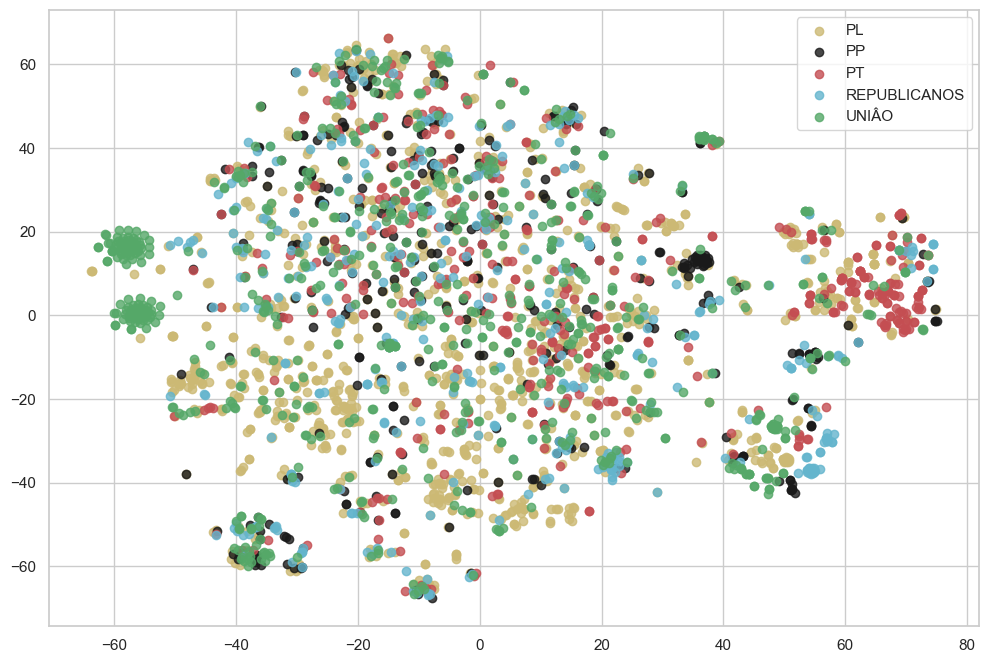

In [305]:
x_data, y_data = tsne_plot(X, y) 

In [311]:
coord_x = [n for n in range(len(x_data[0])) if x_data[0][n] < -40 and y_data[0][n]> -10 and y_data[0][n] < 30 ]

# documentos = [partidos.loc[coord_x[x][2]] for x in range(len(coord_x))]
documentos = []

for x in UNIÃO.itertuples(index=False):
   if x[0] in coord_x[:]:
    documentos.append(x)

In [312]:
documentos = pd.DataFrame(documentos)

In [316]:
documentos.to_csv('Cluster do Partido União.csv')

In [ ]:

# Scaling the data to make it suitable for the auto-encoder 
X_scaled = MinMaxScaler().fit_transform(X) 
X_PL_scaled = X_scaled[y == 0] 
X_PP_scaled = X_scaled[y == 1] 
X_PT_scaled = X_scaled[y == 2] 
X_REPUBLICANOS_scaled = X_scaled[y == 3] 
X_UNIAO_scaled = X_scaled[y == 4] 

In [ ]:
# Building the Input Layer 
input_layer = Input(shape =(X.shape[1], )) 

# Building the Encoder network 
encoded = Dense(100, activation ='relu', 
				activity_regularizer = regularizers.l1(10e-5))(input_layer) 
encoded = Dense(50, activation ='relu', 
				activity_regularizer = regularizers.l1(10e-5))(encoded) 
encoded = Dense(25, activation ='relu', 
				activity_regularizer = regularizers.l1(10e-5))(encoded) 
encoded = Dense(12, activation ='relu', 
				activity_regularizer = regularizers.l1(10e-5))(encoded) 
encoded = Dense(6, activation ='relu')(encoded) 

# Building the Decoder network 
decoded = Dense(12, activation ='relu')(encoded) 
decoded = Dense(25, activation ='relu')(decoded) 
decoded = Dense(50, activation ='relu')(decoded) 
decoded = Dense(100, activation ='relu')(decoded) 

# Building the Output Layer 
output_layer = Dense(X.shape[1], activation ='relu')(decoded) 


In [ ]:

# Defining the parameters of the Auto-encoder network 
autoencoder = Model(input_layer, output_layer) 
autoencoder.compile(optimizer ="adam", loss ="mse") 
  
# Training the Auto-encoder network 
autoencoder.fit(X_scaled, X_scaled,   
                batch_size = 16, epochs = 10,  
                shuffle = True, validation_split = 0.20) 

In [ ]:

hidden_representation = Sequential() 
hidden_representation.add(autoencoder.layers[0]) 
hidden_representation.add(autoencoder.layers[1]) 
hidden_representation.add(autoencoder.layers[2]) 
hidden_representation.add(autoencoder.layers[3]) 
hidden_representation.add(autoencoder.layers[4]) 

In [ ]:
# Separating the points encoded by the Auto-encoder as normal and fraud 
PL_hidden_rep = hidden_representation.predict(X_PL_scaled) 
PP_hidden_rep = hidden_representation.predict(X_PP_scaled) 
PT_hidden_rep = hidden_representation.predict(X_PT_scaled) 
REPUBLICANOS_hidden_rep = hidden_representation.predict(X_REPUBLICANOS_scaled) 
UNIAO_hidden_rep = hidden_representation.predict(X_UNIAO_scaled) 
  
# Combining the encoded points into a single table  
encoded_X = np.append(PP_hidden_rep, PT_hidden_rep,  axis = 0) 
encoded_X = np.append(encoded_X, REPUBLICANOS_hidden_rep, axis = 0 )
encoded_X = np.append(encoded_X, UNIAO_hidden_rep, axis = 0 )
encoded_X = np.append(encoded_X, PL_hidden_rep, axis = 0 )


y_PL = np.full(PL_hidden_rep.shape[0], 0) 
y_PP = np.full(PP_hidden_rep.shape[0], 1) 
y_PT = np.full(PT_hidden_rep.shape[0], 2) 
y_REPUBLICANOS = np.full(REPUBLICANOS_hidden_rep.shape[0],3) 
y_UNIAO = np.full(UNIAO_hidden_rep.shape[0],4) 
 
encoded_y = np.append(y_PP, y_REPUBLICANOS) 
encoded_y = np.append(encoded_y, y_PL) 
encoded_y = np.append(encoded_y, y_PT) 
encoded_y = np.append(encoded_y, y_UNIAO) 
  


In [ ]:
encoded_X

In [ ]:
encoded_y

In [ ]:
# Plotting the encoded points 
tsne_plot(encoded_X, encoded_y) 

In [ ]:

# Splitting the encoded data for linear classification 
X_train_encoded, X_test_encoded, y_train_encoded, y_test_encoded = train_test_split(encoded_X, encoded_y, test_size = 0.2) 
  
# Splitting the original data for non-linear classification 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2) 

In [ ]:
# Building the logistic regression model 
lrclf = LogisticRegression() 
lrclf.fit(X_train_encoded, y_train_encoded) 
  
# Storing the predictions of the linear model 
y_pred_lrclf = lrclf.predict(X_test_encoded) 
  
# Evaluating the performance of the linear model 
print('Accuracy : '+str(accuracy_score(y_test_encoded, y_pred_lrclf))) 

In [ ]:

# # Building the SVM model 
# svmclf = SVC() 
# svmclf.fit(X_train, y_train) 
  
# # Storing the predictions of the non-linear model 
# y_pred_svmclf = svmclf.predict(X_test) 
  
# # Evaluating the performance of the non-linear model 
# print('Accuracy : '+str(accuracy_score(y_test, y_pred_svmclf))) 